In [42]:
%load_ext autoreload
%autoreload 2  # Autoreload all modules

from utils.paths import *
from utils.constants import *
from utils.analysis import *
from utils.plotting import *
from utils.phenofuncs import _find_solstice
import numpy as np
import xarray as xr
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import itertools as it
from matplotlib import rcParams
from dateutil.relativedelta import relativedelta
import calendar
from matplotlib.cm import get_cmap
import warnings
from scipy.stats import linregress, pearsonr
import warnings
from scipy.optimize import minimize 


rcParams['font.size'] = 10
rcParams['axes.titlesize'] = 10
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [43]:
def get_observation():

    # Convert the g biomass to gC
    cconc = pd.read_csv(os.path.join(path_input, 'FRED3_cleaned.csv'))

    picea_rootC = cconc.loc[(cconc['Plant taxonomy_Accepted genus_TPL'] == 'Picea') & (cconc['Plant Taxonomy_Accepted species_TPL'] != 'engelmannii'), 
                            ['Plant taxonomy_Accepted genus_TPL', 'Plant Taxonomy_Accepted species_TPL', 'Root C content']].dropna(axis = 0)
    picea_rootC = picea_rootC['Root C content'].mean() / 1000 # mg/g

    larch_rootC = cconc.loc[(cconc['Plant taxonomy_Accepted genus_TPL'] == 'Larix') & (cconc['Plant Taxonomy_Accepted species_TPL'] == 'decidua'), 
                            ['Plant taxonomy_Accepted genus_TPL', 'Plant Taxonomy_Accepted species_TPL', 'Root C content']].dropna(axis = 0)
    larch_rootC = larch_rootC['Root C content'].mean() / 1000.

    shrub_rootC = cconc.loc[(cconc['Plant taxonomy_Accepted family_TPL'] == 'Ericaceae'), 
                            ['Plant taxonomy_Accepted genus_TPL', 'Plant Taxonomy_Accepted species_TPL', 'Root C content']].dropna(axis = 0)
    shrub_rootC = shrub_rootC['Root C content'].mean() / 1000.


    # Soren's minirhizotron data
    minirhizotron = pd.read_csv(os.path.join(path_input, 'soren_root_prod_mort_growth_20230316.csv'))
    minirhizotron['end_date'] = pd.DatetimeIndex(minirhizotron['end_date']) 
    minirhizotron['start_date'] = pd.DatetimeIndex(minirhizotron['start_date'])
    minirhizotron = minirhizotron.loc[minirhizotron['pft'] != 'sedge']

    # Take the absolute value of mortality rate
    minirhizotron['m_g_d'] = minirhizotron['m_g_d'].abs()

    # Convert from g biomass to gC
    # pima: 0.36, lala: 0.14
    minirhizotron.loc[minirhizotron['pft'] == 'tree', 'm_g_d'] *= (picea_rootC * 0.36 + larch_rootC * 0.14) / 0.5
    minirhizotron.loc[minirhizotron['pft'] == 'tree', 'g_g_d'] *= (picea_rootC * 0.36 + larch_rootC * 0.14) / 0.5
    minirhizotron.loc[minirhizotron['pft'] == 'shrub', 'm_g_d'] *= shrub_rootC
    minirhizotron.loc[minirhizotron['pft'] == 'shrub', 'g_g_d'] *= shrub_rootC

    # 2014-2017 ingrowth core data
    ingrowth = pd.read_csv(os.path.join(path_input, 'spruce_root_ingrowth_2014_2017_20200408.csv'), header = [0, 1], encoding = 'Windows-1252')
    ingrowth.columns = [f'{i} {j}' if not 'Unnamed' in j else f'{i}' for i, j in zip(ingrowth.columns.get_level_values(0), ingrowth.columns.get_level_values(1))]
    ingrowth['start_date yyyy-mm-dd'] = pd.DatetimeIndex(ingrowth['start_date yyyy-mm-dd'])
    ingrowth['end_date yyyy-mm-dd'] = pd.DatetimeIndex(ingrowth['end_date yyyy-mm-dd'])
    ingrowth['root_biomass g m-2 day-1'] = ingrowth['root_biomass g/m2/season'] / np.array([(d.days + 1) for d in (ingrowth['end_date yyyy-mm-dd'] - ingrowth['start_date yyyy-mm-dd'])])
    ingrowth = ingrowth.loc[ingrowth['pft'] != 'graminoid', :]
    ingrowth.loc[ingrowth['pft'] == 'spruce', 'root_biomass g m-2 day-1'] = ingrowth.loc[ingrowth['pft'] == 'spruce', 'root_biomass g m-2 day-1'].values * picea_rootC
    ingrowth.loc[ingrowth['pft'] == 'shrub', 'root_biomass g m-2 day-1'] = ingrowth.loc[ingrowth['pft'] == 'shrub', 'root_biomass g m-2 day-1'].values * shrub_rootC
    ingrowth.loc[ingrowth['pft'] == 'larch', 'root_biomass g m-2 day-1'] = ingrowth.loc[ingrowth['pft'] == 'larch', 'root_biomass g m-2 day-1'].values * larch_rootC

    return minirhizotron, ingrowth

minirhizotron, ingrowth = get_observation()

/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-43-b0eaa7220acb>:4: DtypeWarning: Columns (5,6,7,8,9,15,16,19,20,23,24,32,33,39,40,41,49,54,59,467,504,539,546,570,636,757,758,820,846,849,852,858,859,860,861,862,863,864,866,872,875,877,880,889,906,911,935,990,1000,1037) have mixed types. Specify dtype option on import or set low_memory=False.
  cconc = pd.read_csv(os.path.join(path_input, 'FRED3_cleaned.csv'))


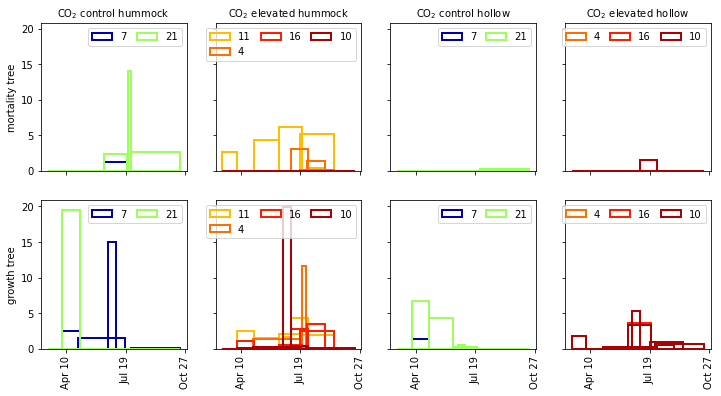

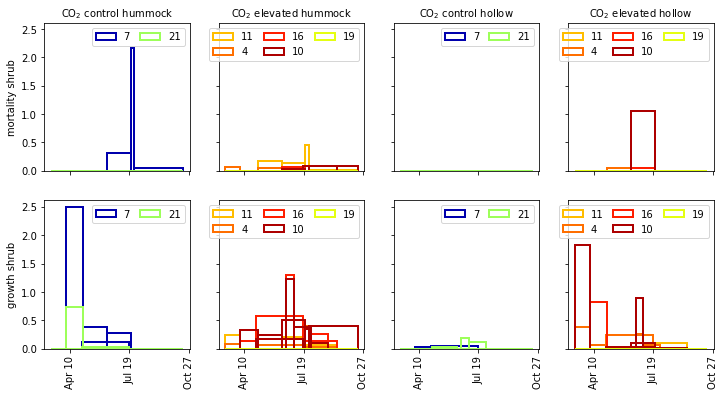

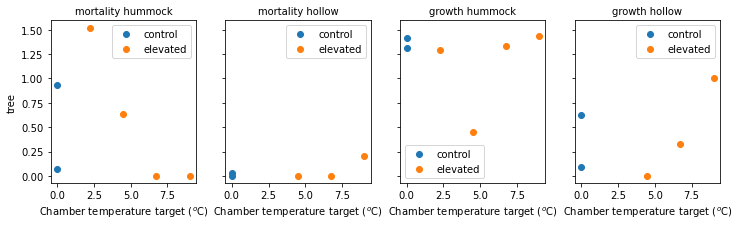

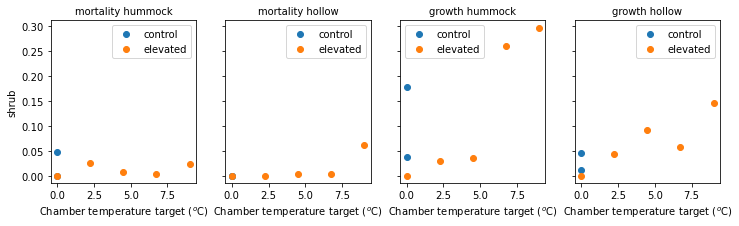

In [4]:
""" Examine Soren's root data
1. The seasonal cycle
2. Relationship between the average growth/mortality rate during the observation period and the temperature of the chamber
"""
cmap = get_cmap('jet')
clist = dict(zip([7, 6, 20, 13, 8, 17, 21, 19, 11, 4, 16, 10], [cmap((i+0.5)/12) for i in range(12)]))

#########################################################################
# The seasonal cycle
#########################################################################
for pft in ['tree', 'shrub']:
    fig, axes = plt.subplots(2, 4, figsize = (12, 6), sharex = True, sharey = True)
    for a, var in enumerate(['m_g_d', 'g_g_d']):
        if var == 'm_g_d':
            varname = 'mortality'
        else:
            varname = 'growth'
        for i, loc in enumerate(['hummock', 'hollow']):
            for j, co2 in enumerate(['control', 'elevated']):
                ax = axes[a, i*2 + j]

                if a == 0:
                    ax.set_title(f'CO$_2$ {co2} {loc}')
                if (i + j) == 0:
                    ax.set_ylabel(f'{varname} {pft}')

                subset = minirhizotron.loc[(minirhizotron['pft'] == pft) & (minirhizotron['co2'] == co2) & (minirhizotron['topo'] == loc), :]
                chambers = subset[['plot', 'temp']].drop_duplicates().set_index('plot')['temp'].sort_values().index

                for k, cha in enumerate(chambers):
                    subset_temp = subset.loc[subset['plot'] == cha, ['start_date', 'end_date', var]]
                    widths = [t.days for t in (subset_temp['end_date'] - subset_temp['start_date'])]

                    # Overlay the individual years
                    mid = [(subset_temp['start_date'].iloc[i] + relativedelta(days = widths[i] // 2)).dayofyear for i in range(subset_temp.shape[0])]

                    ax.bar(x = mid, height = subset_temp[var], width = widths, align = 'center', label = cha, color = 'none', edgecolor = clist[cha], lw = 2)

                # Change the ticks into month-day
                xticks = ax.get_xticks()
                month_days = [datetime(2000, 1, 1) + timedelta(t) for t in xticks]
                labels = [f'{calendar.month_abbr[md.month]} {md.day:02}' for md in month_days]
                ax.set_xticklabels(labels)
                ax.legend(ncol = 3, columnspacing = 1)

                plt.setp(ax.get_xticklabels(), rotation = 90)


#########################################################################
# Relationship between the average growth/mortality rate during the
# observation period and the temperature of the chamber
#########################################################################
annual_growth = minirhizotron.copy()
annual_growth['days'] = np.array([t.days for t in (annual_growth['end_date'] - annual_growth['start_date'])])
annual_growth['m_g_mean'] = annual_growth['m_g_d'] * (annual_growth['days'] + 1)
annual_growth['g_g_mean'] = annual_growth['g_g_d'] * (annual_growth['days'] + 1)
annual_growth = annual_growth.drop(['start_date', 'end_date', 'time_step'], axis = 1 \
    ).groupby(['plot', 'topo', 'temp', 'co2', 'pft', 'year', 'tube']).sum()[['m_g_mean', 'g_g_mean', 'days']]
annual_growth['m_g_mean'] = annual_growth['m_g_mean'] / annual_growth['days']
annual_growth['g_g_mean'] = annual_growth['g_g_mean'] / annual_growth['days']
annual_growth = annual_growth.groupby(['pft', 'topo', 'co2', 'temp', 'plot']).mean()


clist = ['r', 'b']
for i, pft in enumerate(['tree', 'shrub']):
    fig, axes = plt.subplots(1, 4, figsize = (12, 3), sharex = True, sharey = True)
    for j, loc in enumerate(['hummock', 'hollow']):
        for k, var in enumerate(['m_g_mean', 'g_g_mean']):
            if var == 'm_g_mean':
                varname = 'mortality'
            else:
                varname = 'growth'
            ax = axes[k*2 + j]
            ax.set_title(f'{varname} {loc}')
            if (j + k) == 0:
                ax.set_ylabel(pft)
            for m, co2 in enumerate(['control', 'elevated']):        
                temp = annual_growth.loc[(pft, loc, co2), var].reset_index()

                temp.loc[temp['temp'].isin(['ambient', 'control']), 'temp'] = 0. # replace ambient with zero
                temp['temp'] = temp['temp'].astype(float)
                ax.plot(temp['temp'], temp[var], 'o', label = co2)
            ax.set_xlabel('Chamber temperature target ($^o$C)')
            ax.legend()


#########################################################################
# Check the relationship with volumetric soil moisture @ 20 cm, chamber
#########################################################################
hr = xr.open_dataset(os.path.join(path_intrim, 'spruce_validation_data.nc'))
swc = hr['halfhourly_swc'].resample({'time': '1D'}).mean().loc[:, :, 0.2]
swc = pd.DataFrame(swc.values, index = swc['time'].to_index(), columns = swc['chamber']).dropna(how = 'all', axis = 0)
swc = swc.loc[(swc.index.month >= 4) & (swc.index.month <= 10) & (swc.index.year >= 2018), :]
hr.close()

minirhizotron['swc'] = pd.Series(np.nan, index = minirhizotron.index)
for i in minirhizotron.index:
    minirhizotron.loc[i, 'swc'] = swc[minirhizotron.loc[i, 'plot']].loc[minirhizotron.loc[i, 'start_date']:minirhizotron.loc[i, 'end_date']].mean()


annual_growth = minirhizotron.copy()
annual_growth['days'] = np.array([t.days for t in (annual_growth['end_date'] - annual_growth['start_date'])])
annual_growth['m_g_mean'] = annual_growth['m_g_d'] * (annual_growth['days'] + 1)
annual_growth['g_g_mean'] = annual_growth['g_g_d'] * (annual_growth['days'] + 1)
annual_growth['swc'] = annual_growth['swc'] * (annual_growth['days'] + 1) # because there's a sum later
annual_growth = annual_growth.drop(['start_date', 'end_date', 'time_step'], axis = 1 \
    ).groupby(['plot', 'topo', 'temp', 'co2', 'pft', 'year', 'tube']).sum()[['m_g_mean', 'g_g_mean', 'swc', 'days']]
annual_growth['m_g_mean'] = annual_growth['m_g_mean'] / annual_growth['days']
annual_growth['g_g_mean'] = annual_growth['g_g_mean'] / annual_growth['days']
annual_growth['swc'] = annual_growth['swc'] / annual_growth['days']
annual_growth = annual_growth.groupby(['pft', 'topo', 'co2', 'temp', 'plot']).mean()


clist = ['r', 'b']
for i, pft in enumerate(['tree', 'shrub']):
    fig, axes = plt.subplots(1, 4, figsize = (12, 3), sharex = True, sharey = True)
    for j, loc in enumerate(['hummock', 'hollow']):
        for k, var in enumerate(['m_g_mean', 'g_g_mean']):
            if var == 'm_g_mean':
                varname = 'mortality'
            else:
                varname = 'growth'
            ax = axes[k*2 + j]
            ax.set_title(f'{varname} {loc}')
            if (j + k) == 0:
                ax.set_ylabel(pft)
            for m, co2 in enumerate(['control', 'elevated']):        
                temp = annual_growth.loc[(pft, loc, co2), :].reset_index()
                ax.plot(temp['swc'], temp[var], 'o', label = co2)
            ax.set_xlabel('GS mean VWC (m3/m3)')
            ax.legend()



#########################################################################
# Check the relationship with volumetric soil moisture @ 20 cm, annual
#########################################################################
annual_growth = minirhizotron.copy()
annual_growth['days'] = np.array([t.days for t in (annual_growth['end_date'] - annual_growth['start_date'])])
annual_growth['m_g_mean'] = annual_growth['m_g_d'] * (annual_growth['days'] + 1)
annual_growth['g_g_mean'] = annual_growth['g_g_d'] * (annual_growth['days'] + 1)
annual_growth['swc'] = annual_growth['swc'] * (annual_growth['days'] + 1) # because there's a sum later
annual_growth = annual_growth.drop(['start_date', 'end_date', 'time_step'], axis = 1 \
    ).groupby(['plot', 'topo', 'temp', 'co2', 'pft', 'year', 'tube']).sum()[['m_g_mean', 'g_g_mean', 'swc', 'days']]
annual_growth['m_g_mean'] = annual_growth['m_g_mean'] / annual_growth['days']
annual_growth['g_g_mean'] = annual_growth['g_g_mean'] / annual_growth['days']
annual_growth['swc'] = annual_growth['swc'] / annual_growth['days']
annual_growth = annual_growth.groupby(['pft', 'topo', 'plot', 'co2', 'year', 'temp']).mean()


clist = ['r', 'b']
for i, pft in enumerate(['tree', 'shrub']):
    fig, axes = plt.subplots(1, 4, figsize = (12, 3), sharex = True, sharey = True)
    for j, loc in enumerate(['hummock', 'hollow']):
        for k, var in enumerate(['m_g_mean', 'g_g_mean']):
            if var == 'm_g_mean':
                varname = 'mortality'
            else:
                varname = 'growth'
            ax = axes[k*2 + j]
            ax.set_title(f'{varname} {loc}')
            if (j + k) == 0:
                ax.set_ylabel(pft)
            temp = annual_growth.loc[(pft, loc), :]
            for plot in np.unique(temp.index.get_level_values('plot')):
                ax.plot(temp.loc[plot, 'swc'], temp.loc[plot, var], 'o', label = plot)
            ax.set_xlabel('GS mean VWC (m3/m3)')
            ax.legend()

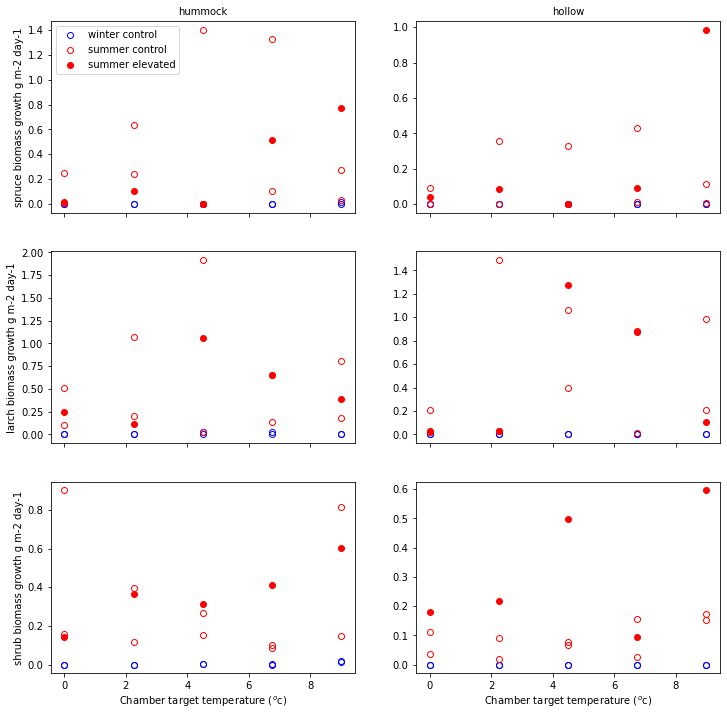

In [6]:
""" Examine the 2015-2017 ingrowth core data: annual biomass in the top 30 cm
Normaization is by area and length of core. The area of the core = the area of the chamber (assume uniform). 
There is very little root below 30cm. Therefore, assume this is equal to the whole soil column.  
"""
season = np.array([d.split('_')[0].lower() for d in ingrowth['season']])

fig, axes = plt.subplots(3, 2, figsize = (12, 12), sharex = True, sharey = False)
for i, pft in enumerate(['spruce', 'larch', 'shrub']):
    for j, topo in enumerate(['hummock', 'hollow']):
        ax = axes[i, j]
        for k, (co2, co2name) in enumerate(zip([0, 500], ['control', 'elevated'])):
            for l, sea in enumerate(['winter', 'summer']):
                subset = ingrowth.loc[(ingrowth['pft'] == pft) & (ingrowth['topog hummock or hollow'] == topo) & (season == sea) & (ingrowth['co2_trmt ppm'] == co2), :]
                if subset.shape[0] != 0:
                    a = subset[['plot', 'temp_target degrees C']].groupby('plot').first().iloc[:, 0]
                    b = subset[['plot', 'root_biomass g m-2 day-1']].groupby('plot').sum().iloc[:, 0]

                    if sea == 'winter':
                        color = 'b'
                    else:
                        color = 'r'
                    if co2name == 'control':
                        fc = 'none'
                    else:
                        fc = color

                    ax.plot(a, b, 'o', color = color, markerfacecolor = fc, label = f'{sea} {co2name}')
        if (i == 0) & (j == 0):
            ax.legend()
        if j == 0:
            ax.set_ylabel(f'{pft} biomass growth g m-2 day-1')
        if i == 0:
            ax.set_title(topo)
        if i == 2:
            ax.set_xlabel('Chamber target temperature ($^o$c)')

In [7]:
""" Convert to fixed parts of the year, and average over all the years
    Convert unit to gC per m2 chamber per day
"""
def expand(x):
    data = 0.64 * x.loc[x.index.get_level_values('topo') == 'hummock', :].values + \
           0.36 * x.loc[x.index.get_level_values('topo') == 'hollow', :].values
    return pd.Series(data.reshape(-1), index = x.columns)


# By observation
""" # cut off by start & end date: 80 - 135, 136 - 225, post-255
plt.hist(pd.DatetimeIndex(minirhizotron['start_date']).dayofyear)
plt.figure()
plt.hist(pd.DatetimeIndex(minirhizotron['end_date']).dayofyear)
plt.figure()
plt.hist((pd.DatetimeIndex(minirhizotron['end_date']) - pd.DatetimeIndex(minirhizotron['start_date'])).days) """


# Skip the zero measurements
# minirhizotron = minirhizotron.loc[(minirhizotron['m_g_d'] > 1e-6) | (minirhizotron['g_g_d'] > 1e-6), :]

# Convert to uniform dates
# ---- average spacing is indeed ~1 month
months = range(1, 13)
date_list = np.cumsum([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
minirhizotron_interp = pd.DataFrame(0., columns = pd.MultiIndex.from_product([['m_g_d', 'g_g_d'], months], names = ['variables', 'months']),
                                    index = pd.MultiIndex.from_product([['tree', 'shrub'], chamber_list_complete], names = ['pft', 'chamber']))
minirhizotron_count = pd.DataFrame(0., columns = pd.MultiIndex.from_product([['m_g_d', 'g_g_d'], months], names = ['variables', 'months']),
                                   index = pd.MultiIndex.from_product([['tree', 'shrub'], chamber_list_complete], names = ['pft', 'chamber']))
date_pairs = minirhizotron[['start_date','end_date']].drop_duplicates()

for ind, row in date_pairs.iterrows():
    subset = minirhizotron.loc[(minirhizotron['start_date'] == row['start_date']) & (minirhizotron['end_date'] == row['end_date']), : ]
    subset = subset.groupby(['pft', 'plot', 'topo']).mean().drop(['tube', 'year'], axis = 1)
    idx = pd.MultiIndex.from_product([subset.index.levels[0], subset.index.levels[1], subset.index.levels[2]], names = ['pft', 'plot', 'topo'])
    subset = subset.reindex(idx).groupby(['pft', 'plot']).apply(expand)
    subset = subset.dropna(axis = 0, how = 'any')

    sdoy = (datetime(1999, row['start_date'].month, row['start_date'].day) - datetime(1999, 1, 1)).days + 1
    edoy = (datetime(1999, row['end_date'].month, row['end_date'].day) - datetime(1999, 1, 1)).days + 1

    # gC m-2; all the days
    for lap in ['m_g_d', 'g_g_d']:
        for i in range(12):
            s = date_list[i]
            e = date_list[i+1]
            overlap = min(edoy, e) - max(s, sdoy) + 1
            if overlap > 0:
                minirhizotron_count.loc[subset.index, (lap, months[i])] = minirhizotron_count.loc[subset.index, (lap, months[i])] + overlap
                minirhizotron_interp.loc[subset.index, (lap, months[i])] = minirhizotron_interp.loc[subset.index, (lap, months[i])].values + subset.loc[:, lap].values * overlap

minirhizotron_interp = (minirhizotron_interp / minirhizotron_count).dropna(axis = 1, how = 'all')
minirhizotron_interp
#minirhizotron_count

variables         m_g_d                                                    \
months               3         4         5         6         7         8    
pft   chamber                                                               
tree  7        0.000000  0.000000  0.000000  0.332837  0.275189  0.000000   
      21       0.000000  0.000000  0.000000  0.436035  1.573702  0.902931   
      6             NaN       NaN       NaN       NaN       NaN       NaN   
      19            NaN       NaN       NaN       NaN       NaN       NaN   
      20       0.000000  0.000000  0.000000  0.065333  0.374106  0.484899   
      11            NaN       NaN       NaN       NaN       NaN       NaN   
      13       0.000000  0.000000  0.000000  0.000000  0.002883  0.045402   
      4        0.000000  0.000000  0.000000  0.000000  0.858877  0.402789   
      8             NaN       NaN  0.000000  0.000000  0.000000  0.000000   
      16       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
      17       0.000000  0.000000  0.000000  0.029313  0.035252  0.000000   
      10       0.000000  0.000000  0.000000  0.005047  0.006064  0.000000   
shrub 7        0.000000  0.000000  0.000000  0.048309  0.143254  0.011716   
      21       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
      6        0.000000  0.057000  0.432650  0.267608  0.115251  0.000000   
      19       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
      20       0.000000  0.000000  0.279538  0.280475  0.255050  0.057764   
      11            NaN       NaN  0.000000  0.000000  0.000000  0.000000   
      13       0.027395  0.004280  0.080896  0.067373  0.093709  0.000000   
      4        0.047552  0.007430  0.021548  0.010654  0.000101  0.000000   
      8        0.000000  0.000000  0.000000  0.122888  0.252546  0.071847   
      16       0.000000  0.000000  0.000000  0.033417  0.040187  0.000000   
      17       0.000000  0.278467  0.040004  0.000000  0.001239  0.010529   
      10       0.000000  0.000000  0.000000  0.113942  0.149592  0.050980   

variables                             g_g_d                                 \
months               9         10        3          4         5         6    
pft   chamber                                                                
tree  7        0.000000  0.000000  0.000000   1.773152  0.254729  2.626149   
      21       1.216994  1.805861  0.000000  12.541388  1.634896  0.371467   
      6             NaN       NaN       NaN        NaN       NaN       NaN   
      19            NaN       NaN       NaN        NaN       NaN       NaN   
      20       0.653560  0.969798  0.000000   2.714184  0.201051  0.557448   
      11            NaN       NaN       NaN        NaN       NaN       NaN   
      13       0.000000  0.000000  0.000000   1.322114  0.799068  0.720093   
      4        0.000000  0.000000  0.000000   0.000000  0.000000  0.084297   
      8        0.000000       NaN       NaN        NaN  1.031705  0.865663   
      16       0.000000  0.000000  0.000000   0.604782  0.087928  0.512369   
      17       0.000000  0.000000  0.000000   0.059132  0.008495  0.338542   
      10       0.000000  0.000000  0.659167   0.123039  0.106716  0.446097   
shrub 7        0.022946  0.034048  0.000000   1.354946  0.258629  0.128495   
      21       0.000000  0.000000  0.000000   0.400765  0.065818  0.024116   
      6        0.000000  0.000000  0.000000   0.178295  0.025614  0.097423   
      19       0.000000  0.000000  0.000000   0.000000  0.000000  0.000000   
      20       0.077856  0.115529  0.215212   0.336523  0.477645  0.336898   
      11       0.000000       NaN       NaN        NaN  0.000000  0.000000   
      13       0.000000  0.000000  0.000000   0.384155  0.101515  0.066842   
      4        0.000000  0.000000  0.183747   0.048507  0.064345  0.063876   
      8        0.093757  0.134837  0.784163   0.122526  0.070379  0.084089   
      16       0.000000  0.000000  0.000000   0.

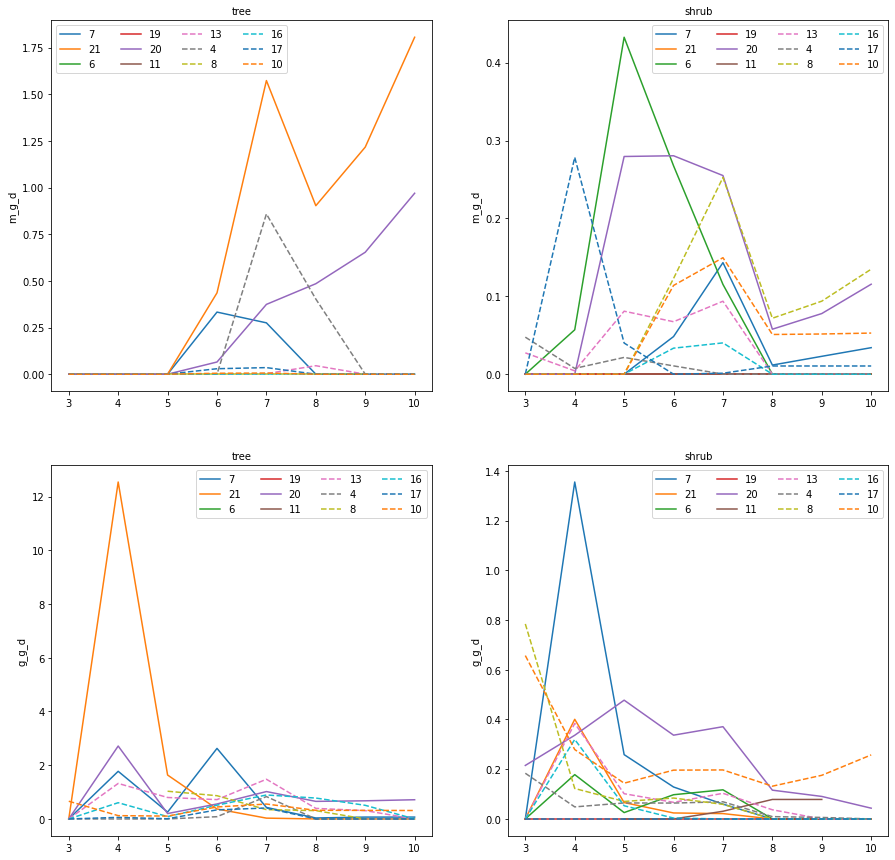

In [8]:
# Oct only has one year's data, which is why m_g_d is greater than Sept and Aug, where some years are zero
fig, axes = plt.subplots(2, 2, figsize = (15, 15))
for i, var in enumerate(['m_g_d', 'g_g_d']):
    for j, ch in enumerate(['tree', 'shrub']):
        ax = axes[i, j]
        for k in range(minirhizotron_interp.loc[ch, var].shape[0]):
            if k >= 6:
                ls = '--'
            else:
                ls = '-' 
            ax.plot(minirhizotron_interp.loc[ch, var].columns, minirhizotron_interp.loc[ch, var].values[k, :], label = minirhizotron_interp.loc[ch, var].index[k], ls = ls )
        ax.set_title(ch)
        ax.set_ylabel(var)
        ax.legend(ncol = 4)

In [9]:
""" Harmonize to 6/10 to 9/22, average over all the years
    Convert unit to gC per m2 chamber per day
"""
ingrowth2 = ingrowth.loc[season == 'summer', :].copy()
ingrowth2 = ingrowth2.groupby(['topog hummock or hollow', 'start_date yyyy-mm-dd', 'end_date yyyy-mm-dd', 'plot', 'pft']).sum()[['root_biomass g m-2 day-1']]
# hummock-hollow averages
ingrowth2 = (ingrowth2.loc['hollow', :] * 0.64 + ingrowth2.loc['hummock', :] * 0.36).dropna(axis = 0)

ingrowth2 = ingrowth2.groupby(['plot', 'pft']).mean()['root_biomass g m-2 day-1'].unstack()
ingrowth2

pft,larch,shrub,spruce
plot,,,
4,0.641578,0.133896,0.000000
6,0.079131,0.099334,0.036785
8,0.153844,0.032775,0.188791
10,0.101138,0.187410,0.231067
11,0.037822,0.081575,0.045151
13,0.065647,0.034554,0.178675
16,0.259123,0.065480,0.072872
17,0.230233,0.101075,0.043285
19,0.039494,0.061872,0.008569


In [10]:
""" Merge into postprocessing data format 
    Hollow and hummock have to be averaged
"""

"""
header = ['Variable', 'Startyear', 'endyear', 'Startday', 'endday', 'averaging period',
          'factor', 'add offset', 'pft', 'obs', 'obs_err', 'treatment']
pft_stride = 17
chamber_list = [6, 19, 20, 11, 13, 4, 8, 16, 17, 10, 7]
chamber_list_names = dict(zip(chamber_list, ['T0.00', 'T0.00CO2', 'T2.25', 'T2.25CO2', 'T4.50', 'T4.50CO2', 'T6.75', 'T6.75CO2', 'T9.00', 'T9.00CO2', 'TAMB']))

f = open(os.path.join('./temp/postproc_vars_SPRUCE_root'), 'w')
f.write('#' + '\t'.join(header) + '\n')


######################################################################
# seasonal minirhizotron observations
######################################################################
factor = 86400 * 2 # convert from gC m-2 s-1 to g biomass m-2 day-1
for elm_var, obs_var in zip(['FROOTC_ALLOC', 'FROOTC_TO_LITTER'], ['g_g_d', 'm_g_d']):
    for pft, pft_id in zip(['tree', 'shrub'], ['2,3', '11']):
        subset = minirhizotron.loc[minirhizotron['pft'] == pft, ['plot', 'topo', 'year', 'start_date', 'end_date', obs_var]]
        ind = subset[['plot', 'start_date', 'end_date']].drop_duplicates()

        # hummock-hollow averages
        aggregate = pd.DataFrame(np.nan, index = pd.MultiIndex.from_frame(ind), columns = [obs_var])
        for _, row in ind.iterrows():
            subset_subset = subset.loc[(subset['plot'] == row['plot']) & \
                                       (subset['start_date'] == row['start_date']) & \
                                       (subset['end_date'] == row['end_date']),
                                       ['topo', obs_var]].set_index('topo')[obs_var]
            # start_doy = pd.DatetimeIndex(subset_subset['start_date']).dayofyear
            # end_doy = pd.DatetimeIndex(subset_subset['end_date']).dayofyear
            if ('hollow' in subset_subset.index) and ('hummock' in subset_subset.index):
                aggregate.loc[tuple(row), :] = subset_subset.loc['hollow'] * 0.64 + subset_subset.loc['hummock'] * 0.36
        aggregate = aggregate.dropna().reset_index()
        aggregate['year'] = pd.DatetimeIndex(aggregate['start_date']).year
        aggregate['start_date'] = pd.DatetimeIndex(aggregate['start_date']).dayofyear
        aggregate['end_date'] = pd.DatetimeIndex(aggregate['end_date']).dayofyear

        for _, line in aggregate.iterrows():
            if not int(line.loc['plot']) in chamber_list:
                continue
            line = f'{elm_var}\t' + str(int(line.loc['year'])) + '\t' + str(int(line.loc['year'])) + '\t' + str(int(line.loc['start_date'])) + \
                   '\t' + str(int(line.loc['end_date'])) + '\t' + str(int(line.loc['end_date'] - line.loc['start_date'])) + '\t' + \
                   str(factor) + f'\t0\t{pft_id}\t' + str(line.loc[obs_var]) + '\t' + str(line.loc[obs_var]) + '\t' + chamber_list_names[int(line.loc['plot'])]
            f.write(line + '\n')


######################################################################
# annual ingrowth cores. Ignore the winter since it is not compatible with postproc and is almost zero. 
# Not sure yet if need to be Growth - Mortality, or just Growth
######################################################################
ingrowth2 = ingrowth.copy()
ingrowth2['root_biomass g m-2 day-1'] = ingrowth['root_biomass g/m2/season'] / (np.array([d.days for d in ingrowth['end_date yyyy-mm-dd'] - ingrowth['start_date yyyy-mm-dd']]) + 1)
ingrowth2 = ingrowth2.groupby(['topog hummock or hollow', 'start_date yyyy-mm-dd', 'end_date yyyy-mm-dd', 'plot', 'pft']).sum()[['root_biomass g m-2 day-1']]
# hummock-hollow averages
ingrowth2 = (ingrowth2.loc['hollow', :] * 0.64 + ingrowth2.loc['hummock', :] * 0.36).dropna(axis = 0)
ingrowth2 = ingrowth2.loc[ingrowth2.index.get_level_values('pft') != 'graminoid', :].reset_index()

factor = 86400 * 2 # convert from gC m-2 s-1 to g biomass m-2 day-1
elm_var = 'FROOTC_ALLOC-FROOTC_TO_LITTER' # !!!!!!!!!!!! NEED TO FIX

for _, row in ingrowth2.iterrows():
    year = row['start_date yyyy-mm-dd'].year

    line = f'{elm_var}\t{year}\t{year}\t' + str(row.loc['start_date yyyy-mm-dd'].dayofyear) + '\t' + \
           str(row.loc['end_date yyyy-mm-dd'].dayofyear) + '\t' + \
           str(row.loc['end_date yyyy-mm-dd'].dayofyear - row.loc['start_date yyyy-mm-dd'].dayofyear + 1) + \
           '\t' + str(factor) + f'\t0\t{pft_id}\t' + str(row.loc['root_biomass g m-2 day-1']) + '\t' + \
           str(row.loc['root_biomass g m-2 day-1']) + '\t' + chamber_list_names[int(row.loc['plot'])]
    f.write(line + '\n')

f.close()
"""

"\nheader = ['Variable', 'Startyear', 'endyear', 'Startday', 'endday', 'averaging period',\n          'factor', 'add offset', 'pft', 'obs', 'obs_err', 'treatment']\npft_stride = 17\nchamber_list = [6, 19, 20, 11, 13, 4, 8, 16, 17, 10, 7]\nchamber_list_names = dict(zip(chamber_list, ['T0.00', 'T0.00CO2', 'T2.25', 'T2.25CO2', 'T4.50', 'T4.50CO2', 'T6.75', 'T6.75CO2', 'T9.00', 'T9.00CO2', 'TAMB']))\n\nf = open(os.path.join('./temp/postproc_vars_SPRUCE_root'), 'w')\nf.write('#' + '\t'.join(header) + '\n')\n\n\n######################################################################\n# seasonal minirhizotron observations\n######################################################################\nfactor = 86400 * 2 # convert from gC m-2 s-1 to g biomass m-2 day-1\nfor elm_var, obs_var in zip(['FROOTC_ALLOC', 'FROOTC_TO_LITTER'], ['g_g_d', 'm_g_d']):\n    for pft, pft_id in zip(['tree', 'shrub'], ['2,3', '11']):\n        subset = minirhizotron.loc[minirhizotron['pft'] == pft, ['plot', 'topo', 'yea

In [11]:
"""
Give set of parameters
* Calculate fine root growth and death rates using default ELM outputs 
* Use `postproc` to compare the calculated values to observations
* Save the metrics to .csv file
"""
def calculator(root_onset, root_dormant, tsoi, tsoi3, swc, psoi, downreg, zwt, sucsat, watsat, bsw, params): # tvec, dt
    """ tvec is DatetimeIndex
        dt is the size of the time step (in seconds)
        The drivers are 1-D numpy arrays indexed by tvec in the first dimension
    """
    # calculate the soil matric potential at wd_thres
    psi_crit = - sucsat * np.power(np.maximum(params['wd_thres'] / watsat, 0.01), -bsw)

    td = np.minimum(params['td_max'], params['td_offset'] + params['td_scale'] * np.power(tsoi - params['td_base'], 2))

    wd_le_base = 0.5 + 1 / np.pi * np.arctan(params['wd_scale'] * np.pi * (np.abs(psoi) - params['wd_base']))
    wd_at_base = 0.5 + 1 / np.pi * np.arctan(params['wd_scale'] * np.pi * (np.abs(psi_crit) - params['wd_base']))
    wd_ge_base = (swc - params['wd_thres']) / (1 - params['wd_thres']) * (1 - wd_at_base) + wd_at_base
    wd = np.where(swc >= params['wd_thres'], wd_ge_base, wd_le_base)

    # mortality rate
    mortality = 1 / (params['froot_long'] * 365 * 86400) * 2 * np.maximum(td, wd)

    # compensatory growth rate
    td_0 = np.minimum(params['td_max'], params['td_offset'] + params['td_scale'] * np.power(params['td_base'], 2))
    m0 = 1 / (params['froot_long'] * 365 * 86400) * 2 * td_0

    growth_compens = np.where(tsoi3 < 0, np.maximum(mortality - m0, 0), 0)

    fnmin = 1 + np.power(downreg, params['downreg_a'])
    fw = np.minimum(1, np.maximum(1 - np.power(zwt, params['zwt_a']) / params['zwt_max'], params['zwt_min']))

    # tvec = [pd.date_range(flist_pft[0].split('.')[-2].split('-')[0] + '-01-01 00:00:00', flist_pft[-1].split('.')[-2].split('-')[0] + '-12-31 23:00:00', freq = '1H')
    # tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
    #filt = (tvec.year == 2015) & (tvec.month == 9) & (tvec.day == 6) & (tvec.hour == 23)
    #print(tsoi[filt] + 273.15, td[filt], params['td_base'], params['td_max'], params['td_scale'], params['td_offset'])
    #print(swc[filt], abs(psi_crit), psoi[filt], params['wd_thres'], wd_at_base, wd[filt], sucsat, watsat, bsw)
    #print(fnmin[filt], fw[filt])

    # transfer growth rate
    growth_onset = fnmin * fw * params['f_stor'] / 86400
    growth_onset = np.where(tsoi3 >= 0, growth_onset, 0)

    growth_onset = np.where(root_onset > 0, growth_onset, 0.)
    growth_compens = np.where(root_dormant > 0, growth_compens, 0)

    return growth_onset, growth_compens, mortality


def extractor(casename, params):
    path_files = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run')

    flist_const = sorted(glob(path_files + '/*.h0.*.nc'))[0]
    flist_col = sorted(glob(path_files + '/*.h1.*.nc'))[:-1]
    flist_pft = sorted(glob(path_files + '/*.h2.*.nc'))[:-1]

    pft_list = [2, 3, 11]
    dt = 3600 # hourly

    if casename.startswith('test_'):
        tvec = pd.date_range(flist_pft[0].split('.')[-2].split('-')[0] + '-01-01 00:00:00', flist_pft[-1].split('.')[-2].split('-')[0] + '-12-31 23:00:00', freq = '1H')
    else:
       tvec = pd.date_range(flist_pft[0].split('.')[-2].split('-')[0] + '-01-01 00:00:00', flist_pft[-1].split('.')[-2].split('-')[0] + '-12-31 00:00:00', freq = '1D')
    tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]

    template = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))
    growth_onset = template.copy() # 1/s
    growth_compens = template.copy() # 1/s
    mortality = template.copy() # 1/s
    root_growth = template.copy() # gC m-2 s-1
    frootc_to_litter = template.copy() # gC m-2 s-1

    hr = xr.open_mfdataset(flist_const)
    sucsat = pd.Series(hr['SUCSAT'][2, :].values, index = ['hummock', 'hollow'])
    watsat = pd.Series(hr['WATSAT'][2, :].values, index = ['hummock', 'hollow'])
    bsw = pd.Series(hr['BSW'][2, :].values, index = ['hummock', 'hollow'])
    dzsoi = hr['DZSOI'].values
    hr.close()

    hr = xr.open_mfdataset(flist_col)
    hr2 = xr.open_mfdataset(flist_pft)
    for pft, loc in it.product(pft_list, ['hummock','hollow']):
        if loc == 'hummock':
            col_id = 0
            pft_id = pft
        else:
            col_id = 1
            pft_id = pft + 17
        
        if pft == 2:
            params['froot_long'] = 3.5 * params['froot_long']
        elif pft == 3:
            params['froot_long'] = 1 * params['froot_long']
        else:
            params['froot_long'] = 1 * params['froot_long']


        if casename.startswith('test_'):
            root_onset = (hr2['ONSET_FLAG_ROOT'][:, pft_id].values > 0)
            root_dormant = (hr2['DORMANT_FLAG_ROOT'][:, pft_id].values > 0)
        else:
            # flag: between winter solstice and date of onset, or not
            leaf_onset = hr2['ONSET_FLAG'][:, pft_id].values
            root_onset = np.zeros(len(leaf_onset))
            root_dormant = np.ones(len(leaf_onset))
            for yy in np.unique(tvec.year):
                if np.sum((tvec.year == yy) & (leaf_onset > 0)) > 0:
                    day0 = np.where((tvec.year == yy) & (leaf_onset > 0))[0][0]
                    day_sol = _find_solstice([yy]).values[0].dayofyear # np.where((tvec.year == yy) & ((tvec.month * 100 + tvec.day) >= 1221))[0][0]
                    root_onset[day0:day_sol] = 1
                    root_dormant[day0:day_sol] = 0

        rootfr = hr2['ROOTFR'][:, :, pft_id].values

        tsoi = np.sum((hr['TSOI'][:, :, col_id].values - 273.15) * rootfr, axis = 1)
        tsoi3 = hr['TSOI'][:, 2, col_id].values - 273.15
        swc = np.sum(hr['SOILLIQ'][:, :, col_id].values / dzsoi[:, col_id].reshape(1, -1) / 1000 * rootfr, axis = 1)
        psoi = np.nanmax(hr['SMP'][:, :, col_id].values, axis = 1)  # mm; need to convert to MPa
        zwt = hr['H2OSFC'][:, col_id].values

        downreg = hr2['DOWNREG'][:, pft_id].values

        growth_onset.loc[:, (str(pft), loc)], growth_compens.loc[:, (str(pft), loc)], mortality.loc[:, (str(pft), loc)] = \
            calculator(root_onset, root_dormant, tsoi, tsoi3, swc, psoi, downreg, zwt, sucsat.loc[loc], watsat.loc[loc], bsw.loc[loc], params)

        # Convert onset rate & compense rate & mortality rate to growth and litterfall rate gC m-2 s-1 -> gC m-2 day-1
        root_growth.loc[:, (str(pft), loc)] = 86400 * np.minimum(growth_onset.loc[:, (str(pft), loc)] + growth_compens.loc[:, (str(pft), loc)], 1 / dt) * hr2['FROOTC_STORAGE'][:, pft_id].values
        frootc_to_litter.loc[:, (str(pft), loc)] = 86400 *mortality.loc[:, (str(pft), loc)] * hr2['FROOTC'][:, pft_id].values

    hr.close()
    hr2.close()
    return growth_onset, growth_compens, mortality, root_growth, frootc_to_litter

In [12]:
""" Sanity check on whether the calculation above generated the same result as the model """

casename = 'test_US-SPR_ICB20TRCNPRDCTCBC'
params = dict(
    td_base = 10,
    td_scale = 0.00175 / 4, 
    td_offset = 0.1, 
    td_max = 0.5, 
    wd_scale = 0.05, 
    wd_base = 35, 
    wd_thres = 0.6, 
    f_stor = 1/180,
    downreg_a = 1,
    zwt_max = 100, # mm
    zwt_a = 1, 
    zwt_min = 0.1, 
    froot_long = 2, 
)


growth_onset, growth_compens, mortality, _, _ = extractor(casename, params)


tvec = pd.date_range('2015-01-01 00:00:00', '2016-12-31 23:00:00', freq = '1H')
tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
growth_onset_sim = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))
growth_compens_sim = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))
mortality_sim = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))


flist = sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h2.*.nc')))[:-1]
hr = xr.open_mfdataset(flist)
for pft, loc in it.product([2, 3, 11], ['hummock', 'hollow']):
    if loc == 'hummock':
        pft_id = pft
    else:
        pft_id = pft + 17
    growth_onset_sim.loc[:, (str(pft), loc)] = hr['ONSET_RATE_FROOT'][:, pft_id].values
    growth_compens_sim.loc[:, (str(pft), loc)] = hr['COMPS_RATE_FROOT'][:, pft_id].values
    mortality_sim.loc[:, (str(pft), loc)] = hr['BGLFR_FROOT'][:, pft_id].values
hr.close()


"""
var = growth_onset # mortality
var_sim = growth_onset_sim # mortality_sim
pft = 3
pft_id = 3 + 17

# filt = (var.loc[:, (str(pft), 'hummock')] > 0.7e-7) & (var.loc[:, (str(pft), 'hummock')] < 0.8e-7) & (var_sim.loc[:, (str(pft), 'hummock')] > 0.8e-7)
filt = np.abs(var.loc[:, (str(pft), 'hollow')] - var_sim.loc[:, (str(pft), 'hollow')]) > 1e-12
print(tvec[filt])

hr = xr.open_mfdataset(sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h1.*.nc')))[:-1])
print(hr['TSOI'][filt, 2, :].values[0, :])
print(hr['H2OSFC'][filt, :].values[0, :])
hr.close()


hr = xr.open_mfdataset(flist)
print(hr['ONSET_FLAG_ROOT'][filt, pft_id].values[0])
print(hr['ONSET_RATE_FROOT'][filt, pft_id].values[0])
ootfr = hr['ROOTFR'].values
hr.close()
hr = xr.open_mfdataset(sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h0.*.nc')))[:-1])
dzsoi = hr['DZSOI'].values
hr.close()
hr = xr.open_mfdataset(sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h1.*.nc')))[:-1])
print(hr['SOILLIQ'][filt, :, 0].values[0, :]) #  / dzsoi[:, 0].reshape(1, -1) / 1000.)
print(rootfr[filt, :, pft_id][0, :])
print(dzsoi)
hr.close()
"""


"""
Some mismatches are probably because the code is accessing the instantaneous value, and the output are hour averages. 
These mismatches are few compared to the timescale of Soren's data. Therefore, parameter calibration will not be affected.
"""
for varname, var, var_sim in zip(['growth_onset', 'growth_compens', 'mortality'], [growth_onset, growth_compens, mortality], [growth_onset_sim, growth_compens_sim, mortality_sim]): 
    fig, axes = plt.subplots(3, 2, figsize = (12, 12))
    for i, pft in enumerate([2, 3, 11]):
        for j, loc in enumerate(['hummock', 'hollow']):
            ax = axes[i, j]

            x = var.loc[:, (str(pft), loc)].values
            y = var_sim.loc[:, (str(pft), loc)].values

            ax.plot(x, y, '.')

            warnings.filterwarnings('ignore')
            res = linregress(x, y)
            rho, pval = pearsonr(x, y)
            warnings.filterwarnings('default')

            ax.plot([x.min(), x.max()], [x.min() * res.slope + res.intercept, x.max() * res.slope + res.intercept], '-k')
            if pval <= 0.05:
                fontweight = 'bold'
            else:
                fontweight = 'normal'
            ax.text(0.05, 0.95, f'{rho:0.3f}', fontweight = fontweight, transform = ax.transAxes)

            ax.set_title(f'pft = {pft}, {loc}')
    fig.savefig(os.path.join('./temp/', f'root_process_check_{varname}.png'), dpi = 600., bbox_inches = 'tight')
    plt.close(fig)

In [56]:
""" Use the default ELM version, convert to the same dates as Soren's observations """
def convert(params, minirhizotron, ingrowth):
    tvec = pd.date_range('2015-01-01 00:00:00', '2020-12-31 00:00:00', freq = '1D')
    tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
    root_growth_collect = pd.DataFrame(index = tvec,
                                    columns = pd.MultiIndex.from_product([['hummock', 'hollow'], chamber_list, ['2', '3', '11']]))
    frootc_to_litter_collect = pd.DataFrame(index = tvec, 
                                            columns = pd.MultiIndex.from_product([['hummock', 'hollow'], chamber_list, ['2', '3', '11']]))
    warnings.filterwarnings('ignore')
    for plot in chamber_list:
        _, _, _, root_growth, frootc_to_litter = extractor(f'20221212_plot{plot:02g}_US-SPR_ICB20TRCNPRDCTCBC', params)
        for col in root_growth.columns:
            root_growth_collect.loc[:, (col[1], plot, col[0])] = root_growth[col].values
            frootc_to_litter_collect.loc[:, (col[1], plot, col[0])] = frootc_to_litter[col].values
    warnings.filterwarnings('default')
    root_growth_collect = root_growth_collect['hummock'] * 0.64 + root_growth_collect['hollow'] * 0.36
    frootc_to_litter_collect = frootc_to_litter_collect['hummock'] * 0.64 + frootc_to_litter_collect['hollow'] * 0.36


    def _expand(x):
        data = 0.64 * x.loc[x.index.get_level_values('topo') == 'hummock', :].values + \
            0.36 * x.loc[x.index.get_level_values('topo') == 'hollow', :].values
        return pd.Series(data.reshape(-1), index = x.columns)


    minirhizotron_average = minirhizotron.drop(['temp', 'co2', 'year', 'time_step', 'npp_km_d', 'm_km_d', 'g_km_d', 'npp_g_d', 'swc', 'tube'], 
                                            axis = 1).set_index(['plot', 'topo', 'pft', 'start_date', 'end_date'])
    idx = pd.MultiIndex.from_product([minirhizotron_average.index.levels[0], minirhizotron_average.index.levels[1], minirhizotron_average.index.levels[2], 
                                    minirhizotron_average.index.levels[3], minirhizotron_average.index.levels[4]], names = ['plot', 'topo', 'pft', 'start_date', 'end_date'])
    minirhizotron_average = minirhizotron_average.reindex(idx).groupby(['plot', 'pft', 'start_date', 'end_date']).apply(_expand)
    minirhizotron_average = minirhizotron_average.dropna(axis = 0, how = 'all')


    ingrowth2 = ingrowth.loc[season == 'summer', :].copy()
    ingrowth2 = ingrowth2.groupby(['topog hummock or hollow', 'plot', 'start_date yyyy-mm-dd', 'end_date yyyy-mm-dd', 'pft']).sum()[['root_biomass g m-2 day-1']]
    # hummock-hollow averages
    ingrowth2 = (ingrowth2.loc['hollow', :] * 0.64 + ingrowth2.loc['hummock', :] * 0.36).dropna(axis = 0)
    ingrowth2 = ingrowth2.iloc[:, 0].unstack()

    minirhizotron_sim = pd.DataFrame(np.nan, index = minirhizotron_average.index, columns = minirhizotron_average.columns)
    for i, _ in minirhizotron_average.iterrows():
        if i[0] in [7, 21]:
            continue # temporarily skip TAMB
        if (i[2].year < 2015) | (i[3].year > 2020):
            continue
        if i[1] == 'tree':
            minirhizotron_sim.loc[i, 'g_g_d'] = root_growth_collect.loc[i[2]:i[3], (i[0], '2')].mean() * 0.36 + root_growth_collect.loc[i[2]:i[3], (i[0], '3')].mean() * 0.14
            minirhizotron_sim.loc[i, 'm_g_d'] = frootc_to_litter_collect.loc[i[2]:i[3], (i[0], '2')].mean() * 0.36 + frootc_to_litter_collect.loc[i[2]:i[3], (i[0], '3')].mean() * 0.14
        elif i[1] == 'shrub':
            minirhizotron_sim.loc[i, 'g_g_d'] = root_growth_collect.loc[i[2]:i[3], (i[0], '11')].mean() * 0.25
            minirhizotron_sim.loc[i, 'm_g_d'] = frootc_to_litter_collect.loc[i[2]:i[3], (i[0], '11')].mean() * 0.25

    ingrowth_sim = pd.DataFrame(np.nan, index = ingrowth2.index, columns = ingrowth2.columns)
    for i, _ in ingrowth2.iterrows():
        if i[0] in [7, 21]:
            continue # temporarily skip TAMB
        if (i[1].year < 2015) | (i[2].year > 2020):
            continue
        ingrowth_sim.loc[i, 'spruce'] = root_growth_collect.loc[i[1]:i[2], (i[0], '2')].mean()
        ingrowth_sim.loc[i, 'larch'] = root_growth_collect.loc[i[1]:i[2], (i[0], '3')].mean()
        ingrowth_sim.loc[i, 'shrub'] = root_growth_collect.loc[i[1]:i[2], (i[0], '11')].mean()

    return minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2


params = dict(
    td_base = 10,
    td_scale = 0.00175 / 4, 
    td_offset = 0.1, 
    td_max = 0.5, 
    wd_scale = 0.05, 
    wd_base = 35,
    wd_thres = 0.6, 
    f_stor = 1/180,
    downreg_a = 1,
    zwt_max = 100, # mm
    zwt_a = 1, 
    zwt_min = 0.1, 
    froot_long = 1
)
minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2 = convert(params, minirhizotron, ingrowth)

/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


KeyboardInterrupt: 

In [25]:
""" Quick plot of the simulation performance """
fig, axes = plt.subplots(1, 3)
for i, col in enumerate(['m_g_d', 'g_g_d']):
    ax = axes.flat[i]
    data = pd.DataFrame({'x': minirhizotron_sim[col], 'y': minirhizotron_average[col]})
    data = data.dropna(axis = 0, how = 'any')
    ax.plot(data['x'], data['y'], '.')
ax = axes.flat[2]
data = pd.DataFrame({'x': ingrowth_sim.stack(), 'y': ingrowth2.stack()})
data = data.dropna(axis = 0, how = 'any')
ax.plot(data['x'], data['y'], '.')

/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


0.0

In [41]:
""" Use Kling-Gupta Efficiency to compare the parameters effects """
def evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2):
    """ Kling-Gupta Efficiency for all and for individual PFTs """

    metrics = pd.DataFrame(index = ['all', 'mort_shrub', 'mort_tree', 'growth_shrub', 'growth_tree', 'ingrowth_larch', 'ingrowth_spruce', 'ingrowth_shrub'], 
                        columns = ['kge', 'r', 'alpha', 'beta'])

    for pft in ['tree', 'shrub']:
        for var1, var2 in zip(['m_g_d', 'g_g_d'], ['mort', 'growth']):
            data = pd.DataFrame({'sim': minirhizotron_sim.loc[(slice(None), pft), var1],
                                'obs': minirhizotron_average.loc[(slice(None), pft), var1]}).dropna(axis = 0, how = 'any')
            metrics.loc[f'{var2}_{pft}', :] = kge(data['sim'].values, data['obs'].values).reshape(-1)
    for pft in ['shrub', 'spruce', 'larch']:
        data = pd.DataFrame({'sim': ingrowth_sim.loc[:, pft], 'obs': ingrowth2.loc[:, pft]}).dropna(axis = 0, how = 'any')
        metrics.loc[f'ingrowth_{pft}', :] = kge(data['sim'].values, data['obs'].values).reshape(-1)

    data = pd.DataFrame({'sim': np.concatenate((minirhizotron_sim.values.reshape(-1), ingrowth_sim.values.reshape(-1))), 
                        'obs': np.concatenate((minirhizotron_average.values.reshape(-1), ingrowth2.values.reshape(-1)))}).dropna(axis = 0, how = 'any')
    metrics.loc['all', :] = kge(data['sim'].values, data['obs'].values).reshape(-1)

    return metrics

metrics = evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2)

/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/home/ywo/Git/phenology_elm/utils/analysis.py:172: RuntimeWarning: invalid value encountered in double_scalars
  r = r_num / r_den


,kge,r,alpha,beta
all,-0.648588,-0.013509,0.092836,0.068498
mort_shrub,NaN,NaN,0.0,0.0
mort_tree,-0.49134,0.274821,0.02221,0.138526
growth_shrub,NaN,NaN,0.0,0.0
growth_tree,-0.761526,-0.050254,0.000022,0.000007
ingrowth_larch,-0.151782,-0.128811,0.984965,0.771612
ingrowth_spruce,NaN,NaN,0.0,0.0
ingrowth_shrub,NaN,NaN,0.0,0.0


In [58]:
""" Maximize the KGE criteria """
def func_mort(vector, minirhizotron, ingrowth):
    # note zwt_max unit is mm
    params = dict(zip(['f_stor', 'downreg_a', 'zwt_max', 'zwt_a', 'zwt_min'], vector))
    # note froot_long is actually scaling factor on the 3.5/1/1 ratios for spruce/larch/shrub
    params.update({
        'td_base': 10,
        'td_scale': 0.00175 / 4, 
        'td_offset': 0.1, 
        'td_max': 0.5, 
        'wd_scale': 0.05, 
        'wd_base': 35,
        'wd_thres': 0.6, 
        'froot_long': 1
    })
    minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2 = convert(params, minirhizotron, ingrowth)
    metrics = evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2)
    return - metrics.loc['mort_shrub', 'kge'] - metrics.loc['mort_tree', 'kge']


def func_growth(vector, minirhizotron, ingrowth, best_mort):
    # note froot_long is actually scaling factor on the 3.5/1/1 ratios for spruce/larch/shrub
    params = dict(zip(['td_base', 'td_scale', 'td_offset', 'td_max', 'wd_scale', 'wd_base', 'wd_thres', 'froot_long'], vector))
    #params.update({
    #    'f_stor': 1/180, 
    #    'downreg_a': 1,
    #    'zwt_max': 100, # mm
    #    'zwt_a': 1, 
    #    'zwt_min': 0.1
    #})
    params.update(dict(zip(['f_stor', 'downreg_a', 'zwt_max', 'zwt_a', 'zwt_min'], best_mort)))
    minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2 = convert(params, minirhizotron, ingrowth)
    metrics = evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2)
    return - metrics.loc['growth_shrub', 'kge'] - metrics.loc['growth_tree', 'kge'] \
           - metrics.loc['ingrowth_larch', 'kge'] - metrics.loc['ingrowth_spruce', 'kge'] \
           - metrics.loc['ingrowth_shrub', 'kge']



params0 = pd.Series(dict(
    td_base = 10,
    td_scale = 0.00175 / 4, 
    td_offset = 0.1, 
    td_max = 0.5, 
    wd_scale = 0.05, 
    wd_base = 35,
    wd_thres = 0.6, 
    f_stor = 1/180,
    downreg_a = 1,
    zwt_max = 100, # mm
    zwt_a = 1, 
    zwt_min = 0.1, 
    froot_long = 1
))

params_range = pd.DataFrame(
    {'td_base': [5, 15], 
     'td_scale': [0.00175/8, 0.00175/2], 
     'td_offset': [0., 0.2], 
     'td_max': [0.5, 1],
     'wd_scale': [0.05, 0.1], 
     'wd_base': [25, 45], 
     'wd_thres': [0.5, 0.9], 
     'froot_long': [0.5, 2], 
     'f_stor': [1/90, 1/360],
     'downreg_a': [0.5, 1.5],
     'zwt_max': [10, 200], 
     'zwt_a': [0.5, 1.5], 
     'zwt_min': [0, 0.5]
    }, index = ['min', 'max']
).T

mort_params = ['td_base', 'td_scale', 'td_offset', 'td_max', 'wd_scale', 'wd_base', 'wd_thres', 'froot_long']
growth_params = ['f_stor', 'downreg_a', 'zwt_max', 'zwt_a', 'zwt_min']

res_mort = minimize(func_mort, params0.loc[mort_params], args = (minirhizotron, ingrowth), 
               bounds = [tuple(row.values) for _, row in params_range.loc[mort_params, :].iterrows()], tol = 1e-12)
res_growth = minimize(func_growth, params0.loc[growth_params], args = (minirhizotron, ingrowth, res_mort.x),
                      bounds = [tuple(row.values) for _, row in params_range.loc[growth_params, :].iterrows()], tol = 1e-12)